In [1]:
"""
Fit per-weight cubic splines over time for ONLY the token embedding matrix tok_emb.weight.

Input expected (from your training code):
  cfg.out_dir/
    manifest.jsonl
    snapshots/
      step_0000001.safetensors
      step_0002000.safetensors
      ...

Output:
  cfg.out_dir/tda_tok_emb_spline.npz
    - t: (T,) float64  (snapshot steps)
    - c: (4, T-1, 113, 128) float32  (piecewise cubic coefficients per weight)
       For segment k between t[k]..t[k+1], spline value is:
         y(τ) = c0 + c1*dx + c2*dx^2 + c3*dx^3,  dx = τ - t[k]
       where c0..c3 are c[:, k, i, j].
Usage:
  fitted = FittedTokEmb.load(npz_path)
  W_hat = fitted.eval(step_float)   # (113,128) float32
"""

import os, re, json, glob
import numpy as np

from safetensors.numpy import load_file as load_safetensors_np

try:
    from scipy.interpolate import CubicSpline
except ImportError as e:
    raise ImportError("This script needs scipy. Install with: pip install scipy") from e


def _read_manifest_steps(manifest_path: str):
    steps = []
    with open(manifest_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            if "step" in obj:
                steps.append(int(obj["step"]))
    # manifest may contain duplicates if you ran multiple times; keep unique sorted
    steps = sorted(set(steps))
    return steps


def _find_snapshot_files(snap_dir: str):
    files = glob.glob(os.path.join(snap_dir, "step_*.safetensors"))
    if not files:
        raise FileNotFoundError(f"No safetensors snapshots found under: {snap_dir}")
    # sort by step extracted from filename
    pat = re.compile(r"step_(\d+)\.safetensors$")
    parsed = []
    for fp in files:
        m = pat.search(fp)
        if m:
            parsed.append((int(m.group(1)), fp))
    parsed.sort(key=lambda x: x[0])
    return parsed  # list of (step, path)


def _load_tok_emb_weight(path: str, key: str = "tok_emb.weight") -> np.ndarray:
    sd = load_safetensors_np(path)
    if key not in sd:
        # help debug: show available keys
        raise KeyError(f"Key '{key}' not found in {os.path.basename(path)}. Keys: {list(sd.keys())[:20]} ...")
    W = sd[key].astype(np.float32, copy=False)
    if W.shape != (113, 128):
        raise ValueError(f"Expected tok_emb.weight shape (113,128), got {W.shape} from {path}")
    return W


def fit_tok_emb_splines(
    out_dir: str,
    key: str = "tok_emb.weight",
    use_manifest: bool = True,
    max_snaps: int | None = None,
    stride: int = 1,
    bc_type: str = "natural",
    save_name: str = "tda_tok_emb_spline.npz",
):
    manifest_path = os.path.join(out_dir, "manifest.jsonl")
    snap_dir = os.path.join(out_dir, "snapshots")

    snaps = _find_snapshot_files(snap_dir)  # (step, path)
    if use_manifest and os.path.exists(manifest_path):
        manifest_steps = set(_read_manifest_steps(manifest_path))
        # keep only snapshots that appear in manifest (optional)
        snaps = [(s, p) for (s, p) in snaps if s in manifest_steps] or snaps

    # stride / max_snaps control
    snaps = snaps[::max(1, int(stride))]
    if max_snaps is not None and len(snaps) > max_snaps:
        snaps = snaps[:max_snaps]

    steps = np.array([s for (s, _) in snaps], dtype=np.float64)  # spline x-axis
    T = len(snaps)
    if T < 2:
        raise ValueError(f"Need at least 2 snapshots for splines; got {T}")

    # Load embeddings into array: (T, 113, 128)
    emb = np.empty((T, 113, 128), dtype=np.float32)
    for k, (_, fp) in enumerate(snaps):
        emb[k] = _load_tok_emb_weight(fp, key=key)

    # Fit cubic splines per weight:
    # We'll use CubicSpline (interpolating) and store piecewise coefficients.
    # For each (i,j), CubicSpline has .c shape (4, T-1), representing
    # y = c0*(x-xk)^3 + c1*(x-xk)^2 + c2*(x-xk) + c3
    #
    # We'll re-order to our preferred form:
    # y = a0 + a1*dx + a2*dx^2 + a3*dx^3
    # so (a0,a1,a2,a3) = (c3,c2,c1,c0)
    c_out = np.empty((4, T - 1, 113, 128), dtype=np.float32)

    # loop weights (113*128 = 14464) — OK for typical T (~hundreds)
    for i in range(113):
        for j in range(128):
            y = emb[:, i, j].astype(np.float64, copy=False)
            sp = CubicSpline(steps, y, bc_type=bc_type, extrapolate=True)
            c = sp.c  # (4, T-1): [dx^3, dx^2, dx^1, dx^0]
            # convert to [dx^0, dx^1, dx^2, dx^3]
            c_out[0, :, i, j] = c[3, :].astype(np.float32)  # a0
            c_out[1, :, i, j] = c[2, :].astype(np.float32)  # a1
            c_out[2, :, i, j] = c[1, :].astype(np.float32)  # a2
            c_out[3, :, i, j] = c[0, :].astype(np.float32)  # a3

    save_path = os.path.join(out_dir, save_name)
    np.savez_compressed(save_path, t=steps, c=c_out)
    print(f"[OK] saved spline coeffs: {save_path}")
    print(f"    t: {steps.shape}  c: {c_out.shape}  (4, T-1, 113, 128)")
    return save_path


class FittedTokEmb:
    """
    Holds per-weight piecewise cubic coefficients for tok_emb.weight.

    Stored:
      t: (T,) strictly increasing
      c: (4, T-1, 113, 128) with y = c0 + c1*dx + c2*dx^2 + c3*dx^3 on each interval
    """

    def __init__(self, t: np.ndarray, c: np.ndarray):
        t = np.asarray(t, dtype=np.float64)
        c = np.asarray(c, dtype=np.float32)
        if t.ndim != 1:
            raise ValueError("t must be 1D")
        if c.shape[0] != 4 or c.shape[1] != (t.size - 1) or c.shape[2:] != (113, 128):
            raise ValueError(f"Bad shapes: t={t.shape}, c={c.shape}")
        if not np.all(np.diff(t) > 0):
            raise ValueError("t must be strictly increasing")
        self.t = t
        self.c = c

    @staticmethod
    def load(npz_path: str) -> "FittedTokEmb":
        data = np.load(npz_path)
        return FittedTokEmb(data["t"], data["c"])

    def eval(self, tau: float) -> np.ndarray:
        """
        Evaluate fitted tok_emb.weight at a (possibly non-integer) step tau.
        Returns: (113,128) float32
        """
        t = self.t
        c = self.c

        # find interval k such that t[k] <= tau < t[k+1]
        # clip to [0, T-2] for extrapolation using end segments
        k = int(np.searchsorted(t, tau, side="right") - 1)
        if k < 0:
            k = 0
        elif k > t.size - 2:
            k = t.size - 2

        dx = np.float32(tau - t[k])
        a0 = c[0, k]
        a1 = c[1, k]
        a2 = c[2, k]
        a3 = c[3, k]
        # y = a0 + a1*dx + a2*dx^2 + a3*dx^3
        return (a0 + dx * (a1 + dx * (a2 + dx * a3))).astype(np.float32, copy=False)





In [2]:

OUT_DIR = "./runs/modadd_grokking_03"

npz = fit_tok_emb_splines(
    out_dir=OUT_DIR,
    key="tok_emb.weight",
    use_manifest=True,
    max_snaps=None,   # set e.g. 600 if you want to cap
    stride=1,         # set e.g. 2/5/10 to downsample snapshots
    bc_type="natural",
    save_name="tda_tok_emb_spline.npz",
)

# quick sanity check
fitted = FittedTokEmb.load(npz)
W0 = fitted.eval(float(fitted.t[0]))
Wm = fitted.eval(float(fitted.t[len(fitted.t)//2]))
W1 = fitted.eval(float(fitted.t[-1]))
print("eval shapes:", W0.shape, Wm.shape, W1.shape)

[OK] saved spline coeffs: ./runs/modadd_grokking_03\tda_tok_emb_spline.npz
    t: (201,)  c: (4, 200, 113, 128)  (4, T-1, 113, 128)
eval shapes: (113, 128) (113, 128) (113, 128)


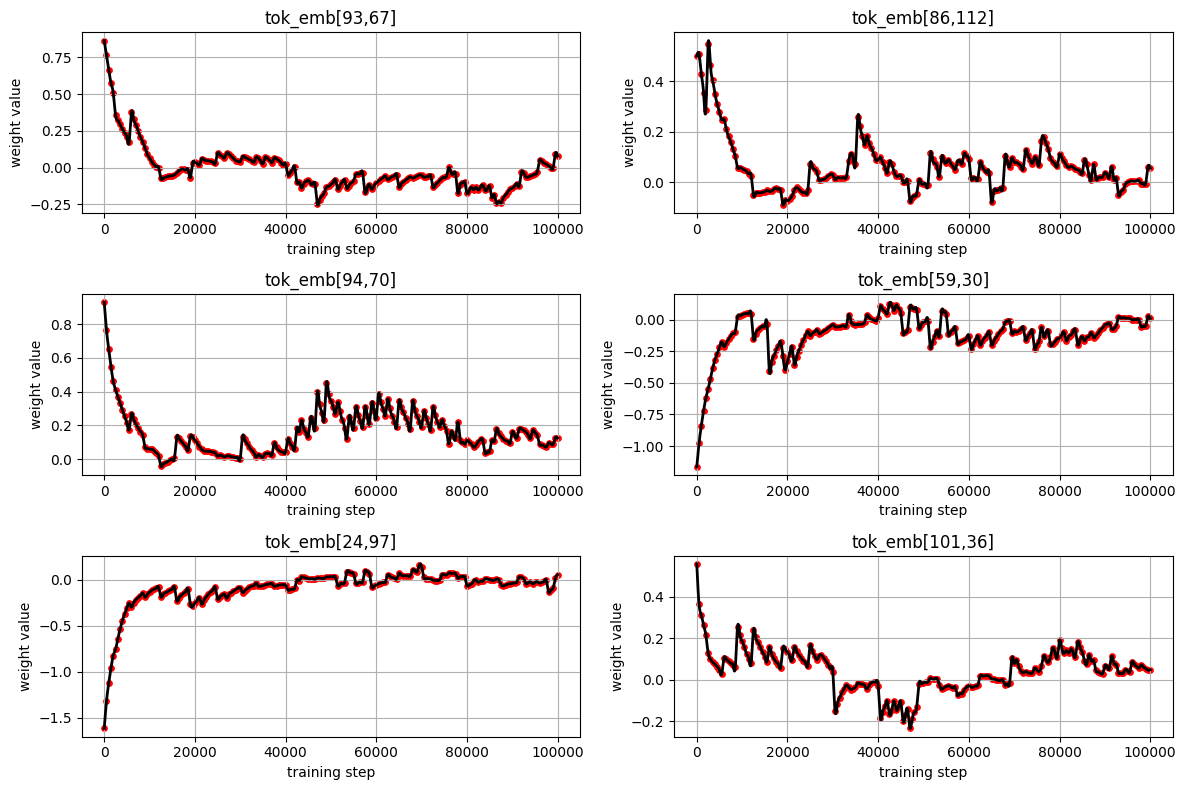

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -------- load fitted splines --------
npz_path = "./runs/modadd_grokking_03/tda_tok_emb_spline.npz"
data = np.load(npz_path)
t = data["t"]          # (T,)
c = data["c"]          # (4, T-1, 113, 128)

T = t.shape[0]

# spline evaluation (same as before, inline for plotting)
def eval_spline(c, t, tau):
    k = np.searchsorted(t, tau, side="right") - 1
    k = np.clip(k, 0, len(t) - 2)
    dx = tau - t[k]
    a0, a1, a2, a3 = c[:, k]
    return a0 + dx * (a1 + dx * (a2 + dx * a3))


# -------- pick random weights --------
num_samples = 6
indices = [(random.randrange(113), random.randrange(128))
           for _ in range(num_samples)]

# dense time grid for smooth curve
t_dense = np.linspace(t[0], t[-1], 2000)

plt.figure(figsize=(12, 8))

for idx, (i, j) in enumerate(indices, 1):
    y_dense = np.array([
        eval_spline(c[:, :, i, j], t, tau)
        for tau in t_dense
    ])

    # original discrete samples
    y_disc = [
        eval_spline(c[:, :, i, j], t, tk)
        for tk in t
    ]

    plt.subplot(3, 2, idx)
    plt.plot(t_dense, y_dense, color="black", lw=2, label="spline")
    plt.scatter(t, y_disc, color="red", s=15, label="snapshots")
    plt.title(f"tok_emb[{i},{j}]")
    plt.xlabel("training step")
    plt.ylabel("weight value")
    plt.grid(True)

plt.tight_layout()
plt.show()


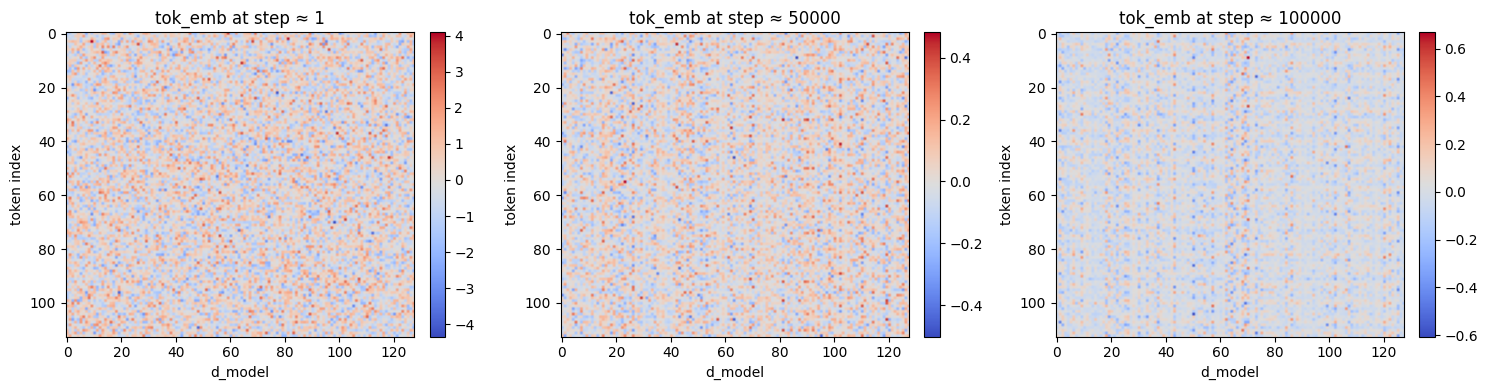

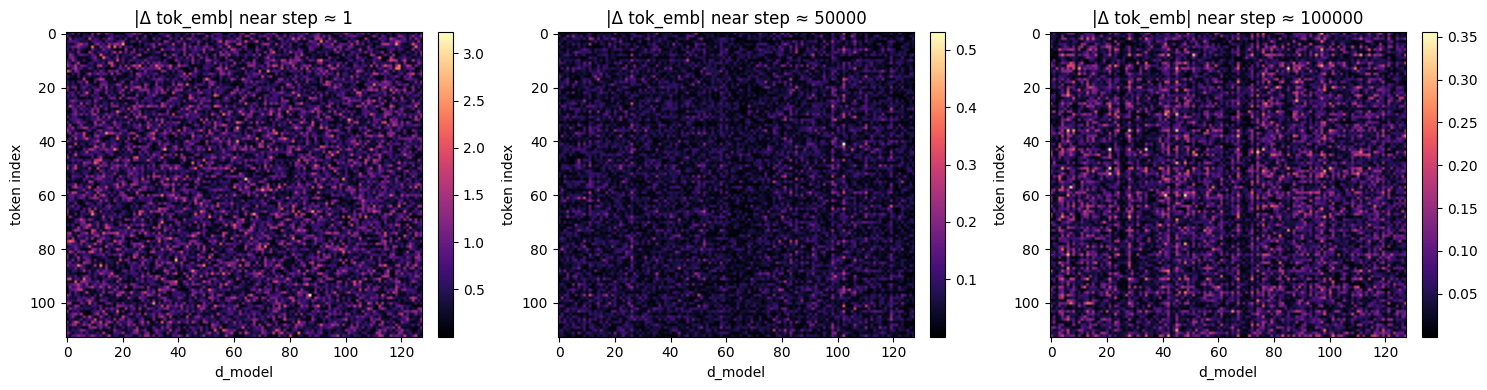

In [6]:
# choose a few representative times
times_to_plot = [
    t[0],                   # early
    t[len(t)//2],           # mid
    t[-1],                  # late
]

plt.figure(figsize=(15, 4))

for k, tau in enumerate(times_to_plot, 1):
    W = eval_spline(c, t, tau)   # (113,128)

    plt.subplot(1, 3, k)
    im = plt.imshow(W, aspect="auto", cmap="coolwarm")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"tok_emb at step ≈ {int(tau)}")
    plt.xlabel("d_model")
    plt.ylabel("token index")

plt.tight_layout()
plt.show()


def eval_delta(c, t, tau, dt=2000):
    return np.abs(
        eval_spline(c, t, tau) -
        eval_spline(c, t, tau - dt)
    )

plt.figure(figsize=(15, 4))

for k, tau in enumerate(times_to_plot, 1):
    D = eval_delta(c, t, tau)

    plt.subplot(1, 3, k)
    im = plt.imshow(D, aspect="auto", cmap="magma")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"|Δ tok_emb| near step ≈ {int(tau)}")
    plt.xlabel("d_model")
    plt.ylabel("token index")

plt.tight_layout()
plt.show()
